In [16]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [17]:
import kagglehub
path = kagglehub.competition_download("santander-customer-transaction-prediction")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

Dataset downloaded to: /root/.cache/kagglehub/competitions/santander-customer-transaction-prediction
['train.csv', 'sample_submission.csv', 'test.csv']


In [18]:
import pandas as pd

df = pd.read_csv(f"{path}/train.csv")
print(df.shape)
df.head()

(200000, 202)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [19]:
print(df.isnull().sum().sum())
print(df['target'].value_counts(normalize=True))  # check the imbalance

0
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


In [20]:
X = df.drop(['ID_code', 'target'], axis=1)
y = df['target']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

results = []
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results.append((C, train_acc, test_acc))
    print(f"C={C}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")

C=0.01: Train Acc=0.7821, Test Acc=0.7833
C=0.1: Train Acc=0.7822, Test Acc=0.7833
C=1: Train Acc=0.7821, Test Acc=0.7834
C=10: Train Acc=0.7821, Test Acc=0.7834
C=100: Train Acc=0.7821, Test Acc=0.7834


In [25]:
best_C = 1  # replace with whatever your sweep shows is best
final_model = LogisticRegression(C=best_C, max_iter=1000, class_weight='balanced')
final_model.fit(X_train_scaled, y_train)

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns

y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000

ROC-AUC: 0.8598998891036755


In [27]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    print(f"C={C}: Train Acc={model.score(X_train_scaled, y_train):.4f}, "
          f"Test Acc={model.score(X_test_scaled, y_test):.4f}, "
          f"ROC-AUC={roc_auc_score(y_test, y_prob):.4f}")

C=0.01: Train Acc=0.7821, Test Acc=0.7833, ROC-AUC=0.8599
C=0.1: Train Acc=0.7822, Test Acc=0.7833, ROC-AUC=0.8599
C=1: Train Acc=0.7821, Test Acc=0.7834, ROC-AUC=0.8599
C=10: Train Acc=0.7821, Test Acc=0.7834, ROC-AUC=0.8599
C=100: Train Acc=0.7821, Test Acc=0.7834, ROC-AUC=0.8599


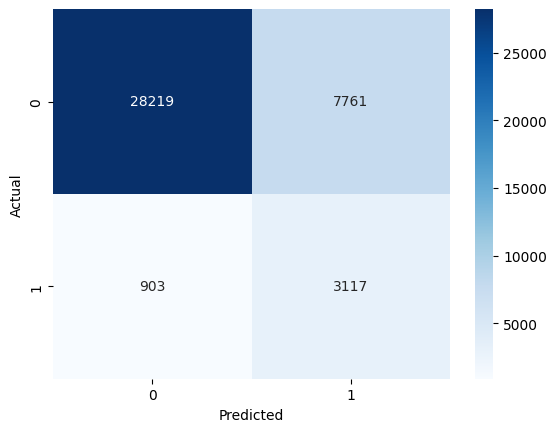

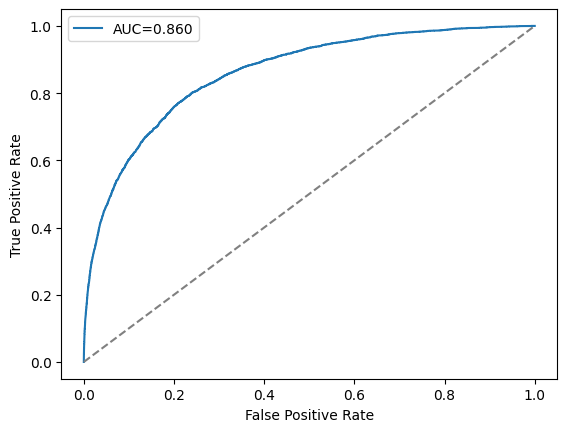

In [26]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.show()